<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20Force009.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
grid_size = 512
e_folds = 10000
lambda_A = 1.000000
lambda_B = 1.000003
beta_vacuum = 1/64  # Hypothetical vacuum–vacuum coupling


In [ ]:
def generate_void_field(grid_size, lam):
    x = np.linspace(0, 4*np.pi, grid_size)
    y = np.linspace(0, 4*np.pi, grid_size)
    X, Y = np.meshgrid(x, y)
    return lam * (np.sin(X) + np.sin(Y))


In [ ]:
def vacuum_coupling(void_A, void_B, beta=1/64):
    grad_A_x, grad_A_y = np.gradient(void_A)
    grad_B_x, grad_B_y = np.gradient(void_B)

    theta_A = np.arctan2(grad_A_y, grad_A_x)
    theta_B = np.arctan2(grad_B_y, grad_B_x)
    phase_diff = theta_A - theta_B

    modulation = -beta * np.sin(phase_diff)
    void_A += modulation
    void_B -= modulation
    return void_A, void_B


In [ ]:
def evolve_field(field, steps, decay=0.9999):
    evolved = field.copy()
    for _ in range(steps):
        evolved *= decay
        evolved += np.random.normal(0, 0.001, field.shape)
    return evolved


In [ ]:
def memory_fidelity(original, evolved):
    return np.corrcoef(original.flatten(), evolved.flatten())[0,1]

def residual_energy(field):
    return np.mean(field**2)


Void A fidelity: 0.9843
Void B fidelity: 0.9844
Residual echo energy: 0.008640


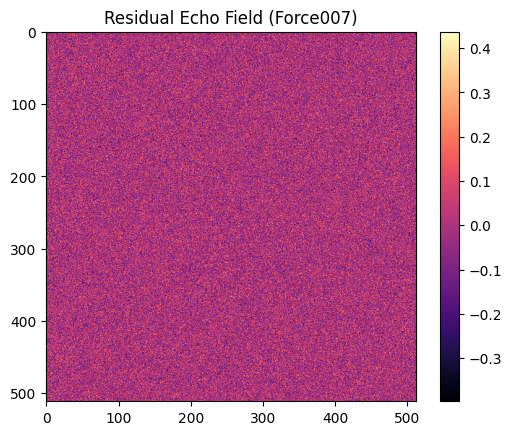

In [ ]:
void_A = generate_void_field(grid_size, lambda_A)
void_B = generate_void_field(grid_size, lambda_B)
void_A_c, void_B_c = vacuum_coupling(void_A, void_B, beta_vacuum)

void_A_e = evolve_field(void_A_c, e_folds)
void_B_e = evolve_field(void_B_c, e_folds)

f_A = memory_fidelity(void_A_c, void_A_e)
f_B = memory_fidelity(void_B_c, void_B_e)
residual = residual_energy(void_A_e - void_B_e)

print(f"Void A fidelity: {f_A:.4f}")
print(f"Void B fidelity: {f_B:.4f}")
print(f"Residual echo energy: {residual:.6f}")

plt.imshow(void_A_e - void_B_e, cmap='magma')
plt.title("Residual Echo Field (Force007)")
plt.colorbar()
plt.show()
